In [1]:
# import
import os, sys, platform
import numpy as np
import pandas as pd

# import plotting libraries
import matplotlib.pyplot as plt

In [2]:
# import functions from snaplab tools
os_name = platform.system()
print(f"Current OS is: {os_name}")

if os_name == "Linux":
    sys.path.extend([r'/home/lindenmp/research_projects/snaplab_tools'])
elif os_name == "Darwin":
    sys.path.extend([r'/Users/lindenmp/research_projects/snaplab_tools'])
from snaplab_tools.topology import threshold_adjacency_consistency
from snaplab_tools.plotting.plotting import plot_correlation

Current OS is: Darwin


# Load data

First, let's load some data from the HCP. 

We will load a 3D numpy matrix (n_nodes, n_nodes, n_subjects) that contains structural connectomes for a bunch of subjects.

Note, this data is not provided with this tutorial. If you want to execute this notebook, you will need to provide your own data.

In [3]:
# directory where data is stored
if os_name == "Linux":
    in_dir = '/home/lindenmp/research_projects/nct_xr/data'
elif os_name == "Darwin":
    in_dir = '/Users/lindenmp/Google-Drive-Personal/work/data'

adjacency_file = os.path.join(in_dir, 'HCPYA_Schaefer4007_A.npy')
adjacency = np.load(adjacency_file)
print(adjacency.shape)

(400, 400, 960)


Next, we will average over subjects.

In [4]:
adjacency_mean = np.mean(adjacency, axis=-1)
print(adjacency_mean.shape)

(400, 400)


Then, we will use threshold_adjacency_consistency to get the average connectome again, but this time we will only retain edges that have non-zero values in at least 60% of our subjects.

In [5]:
adjacency_mean_thr = threshold_adjacency_consistency(adjacency, thr=0.6)
print(adjacency_mean_thr.shape)

(400, 400)


Finally, we will compare to two mean connectomes to see the effect of thresholding.

In [6]:
adjacency_indices = np.triu_indices(n=adjacency_mean.shape[0], k=1)

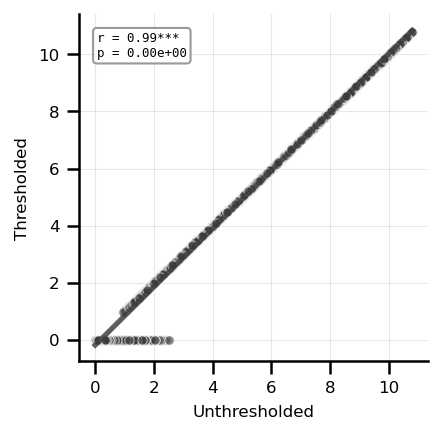

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), dpi=150)
plot_correlation(adjacency_mean[adjacency_indices], adjacency_mean_thr[adjacency_indices], axes,
                 x_label='Unthresholded', y_label='Thresholded', font_size=8)
plt.show()

You can see that there are a handful of weak edges that are non-zero in the original unthresholded mean connectome (x-axis), but have been set to 0 in the thresholded version (y-axis).

Note, while these connections are weak, it is not simply that weak connections are being thresholded out. You can also see that there are some weak connections (edges weight values around ~1-2) that have been preserved in the thresholded connectome. These weak connections are stable across subjects (at least 60%). Thus, the assumption here is that we have retained the weak but stable connections, and removed the weak but *unstable* connections.